# Sales Analytics & Business Insights

### Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\user\Desktop\online_retail_task2_students.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(df.info())
print(df.shape)
print(df.head())


### Load Dataset

In [ ]:
df = pd.read_csv(r"C:\Users\user\Desktop\online_retail_task2_students.csv")



### Data Overview

In [ ]:
print(df.info())
print(df.shape)
print(df.head())

### Prepare Analysis Dataset

In [72]:
# create a clean dataset for analysis
df_clean = df.drop_duplicates().copy()

# remove missing descriptions and invalid transactions
df_clean = df_clean.dropna(subset=['Description'])
df_clean = df_clean[
    (df_clean['Quantity'] > 0) &
    (df_clean['UnitPrice'] > 0)
].copy()

# calculate sales value
df_clean['Sales'] = df_clean['Quantity'] * df_clean['UnitPrice']

# prepare the analysis dataset
analysis_df = df_clean.copy()

print(analysis_df.info())
print(analysis_df.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 19570 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    19570 non-null  object 
 1   StockCode    19570 non-null  object 
 2   Description  19570 non-null  object 
 3   Quantity     19570 non-null  int64  
 4   InvoiceDate  19570 non-null  object 
 5   UnitPrice    19570 non-null  float64
 6   CustomerID   14526 non-null  float64
 7   Country      19570 non-null  object 
 8   Sales        19570 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 1.5+ MB
None
(19570, 9)


## Sales Overview


In [73]:
# total sales
total_sales = analysis_df['Sales'].sum()
print(f"Total Sales: ${total_sales:,.2f}")

# average sales 
average_sales = analysis_df['Sales'].mean()
print(f"Average Sales: ${average_sales:,.2f}")

# highest sale
highest_sale = analysis_df['Sales'].max()
print(f"Highest Sale: ${highest_sale:,.2f}")

# lowest sale
lowest_sale = analysis_df['Sales'].min()
print(f"Lowest Sale: ${lowest_sale:,.2f}")

# total quantity sold
total_quantity_sold = analysis_df['Quantity'].sum()
print(f"Total Quantity Sold: {total_quantity_sold}")

# number of unique invoices
unique_invoices = analysis_df['InvoiceNo'].nunique()
print(f"Number of Unique Invoices: {unique_invoices}")

# number of unique customers
unique_customers = analysis_df['CustomerID'].nunique()
print(f"Number of Unique Customers: {unique_customers}")

# number of unique products
unique_products = analysis_df['StockCode'].nunique()
print(f"Number of Unique Products: {unique_products}")

Total Sales: $362,902.28
Average Sales: $18.54
Highest Sale: $3,035.52
Lowest Sale: $0.12
Total Quantity Sold: 194265
Number of Unique Invoices: 9082
Number of Unique Customers: 3059
Number of Unique Products: 2831


## Product Analysis

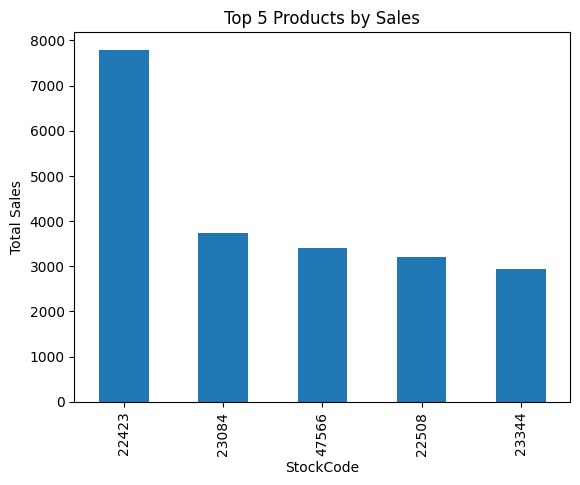

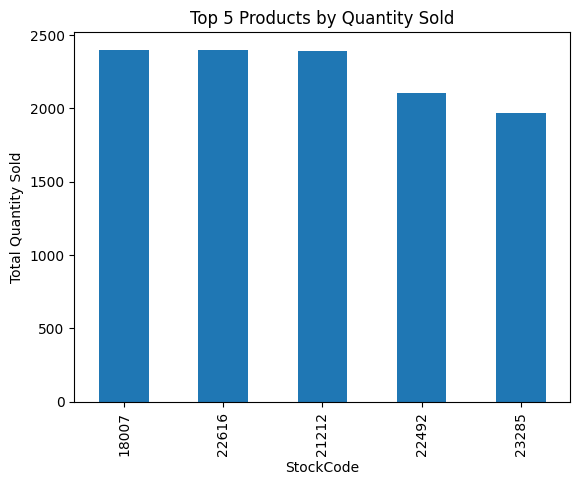

In [74]:
# top 5 products by sales
top_products = (
    analysis_df[analysis_df['StockCode'] != 'DOT']
    .groupby('StockCode')['Sales']
    .sum()
    .nlargest(5)
)
top_products.plot(kind='bar', title='Top 5 Products by Sales')
plt.xlabel('StockCode')
plt.ylabel('Total Sales')
plt.show()

# top 5 products by quantity sold
top_products_quantity = (
    analysis_df[analysis_df['StockCode'] != 'DOT']
    .groupby('StockCode')['Quantity']
    .sum()
    .nlargest(5)
)

top_products_quantity.plot(kind='bar', title='Top 5 Products by Quantity Sold')
plt.xlabel('StockCode')
plt.ylabel('Total Quantity Sold')
plt.show()


## Customer Analysis

In [75]:
# top 5 customers by sales
top_customers = (analysis_df.groupby("CustomerID")["Sales"].sum().nlargest(5))
print("Top 5 Customers by Sales:")
print(top_customers)

# average payment per customer
average_payment_per_customer = analysis_df.groupby("CustomerID")["Sales"].mean()
print("Average Payment per Customer:")
print(average_payment_per_customer)

# loyalty analysis: number of customers with more than one purchase
loyal_customers= analysis_df.groupby("CustomerID").filter(lambda x: len(x) > 1)["CustomerID"].nunique()
print(f"Number of Loyal Customers (more than one purchase): {loyal_customers}")

Top 5 Customers by Sales:
CustomerID
14646.0    11175.25
17450.0     7291.84
18102.0     5241.14
14911.0     5080.39
17511.0     4609.06
Name: Sales, dtype: float64
Average Payment per Customer:
CustomerID
12347.0    16.883333
12348.0    53.920000
12349.0    71.826000
12352.0    20.650000
12354.0    16.725000
             ...    
18265.0    16.600000
18272.0    13.220000
18276.0    25.200000
18277.0    13.520000
18283.0     2.785652
Name: Sales, Length: 3059, dtype: float64
Number of Loyal Customers (more than one purchase): 2125


## Country Analysis

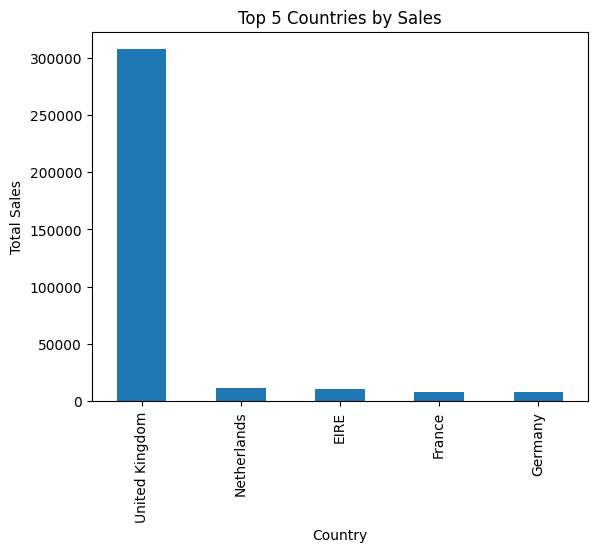

In [76]:
# top countries by sales
top_countries=analysis_df.groupby("Country")["Sales"].sum().nlargest(5)
top_countries.plot(kind="bar", title="Top 5 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.show()
            

In [77]:
# top country by unique customers
top_country_by_customers= analysis_df.groupby("Country")["CustomerID"].nunique().nlargest(1)
print("Top Country by Unique Customers:")
print(top_country_by_customers)

Top Country by Unique Customers:
Country
United Kingdom    2742
Name: CustomerID, dtype: int64


## Monthly Sales Analysis

      Month  Monthly Sales
0   2010-12       25395.34
1   2011-01       19640.81
2   2011-02       19979.93
3   2011-03       27000.78
4   2011-04       19491.13
5   2011-05       26322.43
6   2011-06       21927.30
7   2011-07       27267.31
8   2011-08       24390.21
9   2011-09       39698.62
10  2011-10       40876.07
11  2011-11       52507.18
12  2011-12       18405.17


(array([492]), [Text(492, 0, 'Jan\n2011')])

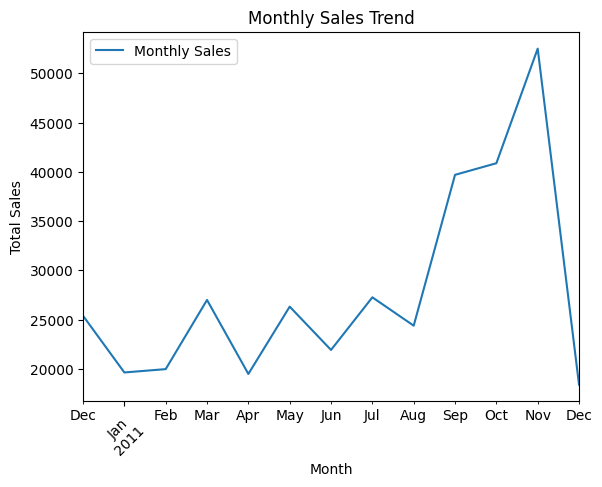

In [84]:

# monthly sales table
analysis_df['InvoiceDate'] = pd.to_datetime(analysis_df['InvoiceDate'])

monthly_sales = (
    analysis_df.groupby(analysis_df['InvoiceDate'].dt.to_period('M'))['Sales']
    .sum()
    .reset_index()
)

monthly_sales.columns = ['Month', 'Monthly Sales']
print(monthly_sales)
monthly_sales.plot(x='Month', y='Monthly Sales', kind='line', title='Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

### Key Insights

1. **DOT appeared among the highest-selling items by revenue.** However, DOT represents a postage/shipping charge rather than an actual product, so it was excluded from the product ranking.

2. **The top-selling products by revenue are significantly different from the most frequently purchased products by quantity.** This can be explained by differences in product prices: some products are ordered in large quantities but are relatively inexpensive, while higher-priced products can generate greater revenue despite having lower sales volumes.

3. **The United Kingdom significantly outperforms the other countries in sales.** Its sales are more than 15 times higher than those of the Netherlands, the next-highest country, indicating a strong concentration of revenue in the UK market.

4. **Sales fluctuate noticeably across the months.** November 2011 recorded the highest sales by a significant margin, while December 2011 recorded the lowest. However, December should be interpreted carefully because the available data only covers the first nine days of the month rather than the full month.

5. **There is no consistent upward or downward trend in monthly sales.** Instead, sales fluctuate from month to month, with November 2011 standing out as an exceptional peak.


## Recommendations



1. **Focus on the UK market**
   Since the United Kingdom generates significantly higher sales than other countries, the company should focus more marketing and promotional efforts on this market.

2. **Maintain stock of high-performing products**
   The company should ensure that its highest-revenue products are well stocked to meet existing demand and avoid missed sales opportunities.

3. **Investigate low-performing months**
   Sales are relatively low in January, February, and April. The company should investigate the reasons behind this pattern and develop seasonal strategies to improve sales during these periods.

4. **Review low-performing markets**
   Countries such as the Netherlands and Ireland generate relatively low sales. The company should compare their revenue with delivery and operational costs to determine whether these markets are profitable and whether changes to the sales strategy are needed.
